### Troubleshooting

In [1]:
import torch
import torchio as tio
import yaml
import matplotlib.pyplot as plt

from pkg.data.datasets import ADNIDataset, TransformDataset
from pkg.data.datamodules import ADNIDataModule
from pkg.utils.instantiate import instantiate
from pkg.models.poe import PoE
from pkg.data.augmentation import build_augmentation
from torch.utils.data import DataLoader, Subset

from pkg.models.poe import PoE
from torch.nn import CrossEntropyLoss

from itertools import combinations

import numpy as np

/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("./config.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNIDataModule', 'args': {'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-FBB': ['PET-FBB']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 4, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE', 'args': {'n_modalities': 1, 'n_classes': 3}}, 'optimizer': {'name': 'AdamW', 'params

In [3]:
dm = instantiate(cfg["datamodule"])
dm.setup()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


In [4]:
dm.set_fold(0)

In [7]:
model = PoE(3, 1)

counts = np.bincount(dm.train_labels)
weights = (1.0 / counts)
weights = weights/weights.sum()
w = torch.tensor(weights, dtype=torch.float32)

criterion = CrossEntropyLoss(weight=w)
criterion.reduction = "none"

model.set_criterion(criterion)

In [8]:
weights

array([0.34759838, 0.20052373, 0.45187789])

In [9]:


for batch in dm.train_dataloader(1):

    mask = batch["mask"]
    X = batch["X"]
    y = batch["y"]

    #print(X.shape)
    #print(y.shape)

    loss, out = model.train_batch(batch, 1)
    print(f"Loss {loss.item()} ")
    
    #break
    # out = {}

    # loss = 0
    
    # for r in range(1, n_modalities+1):
    #     for combo in combinations([ i for i in range(n_modalities)], r):

    #         # Mask samples with all modalities available 
    #         current_mask = torch.prod(mask[ :, combo], dim=1)

    #         print(f" Current mask: {current_mask}")

    #         print(f"Forward {model(X, combo) }")
            
    #         # Compute masked loss
    #         l = criterion( model(X, combo), y)
    #         l = ( l*current_mask ).sum()/current_mask.sum()

    #         print(f" l : {l}")

    #         # Save loss to output dict
    #         out[ "loss_" + "".join([ str(c) for c in combo])] = l.item()

    #         # Add to total
    #         loss += l
    
    break

Loss 1.0988216400146484 


### Test

In [6]:
import yaml

from pkg.data.datasets import ADNIDataset
from pkg.data.datamodules import ADNIDataModule

from pkg.utils.instantiate import instantiate

import matplotlib.pyplot as plt

In [5]:
with open("./config.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNIDataModule', 'args': {'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-FBB': ['PET-FBB']}}, 'split': {'mode': 'kfold', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 4, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE', 'args': {'n_modalities': 1, 'n_classes': 3}}, 'optimizer': {'name': 'AdamW', 'params

In [6]:
dm = instantiate(cfg["datamodule"])
dm.setup()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


In [7]:
dm.ds.df_multimodal

,PET-FBB,diagnosis,subject_id,strat_key,label
0,I1594117,1.0,006_S_4485,11,0
1,I1594205,1.0,006_S_6209,11,0
2,I1610460,1.0,006_S_6209,11,0
3,I10939874,1.0,006_S_6209,11,0
4,I1594133,1.0,006_S_6234,11,0
...,...,...,...,...,...
962,I1614548,1.0,941_S_7051,11,0
963,I10936211,2.0,941_S_7051,21,1
964,I1614614,1.0,941_S_7074,11,0
965,I10311819,1.0,941_S_7074,11,0


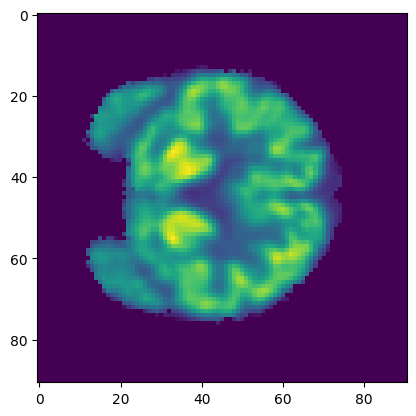

In [10]:

index = 70
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

plt.imshow(sample[0,:,70,:])


In [63]:
print(diag)

tensor(1)


tensor(2)


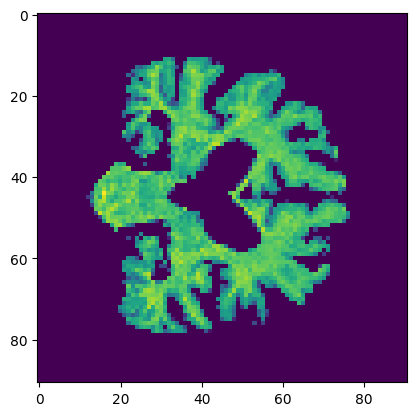

In [66]:
index = 34
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

print(diag)
plt.imshow(sample[0,:,50,:])

In [58]:
print(diag)

tensor(0)


tensor(0)


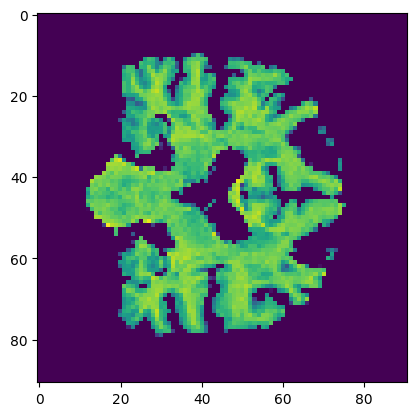

In [64]:
index = 40
diag = dm.ds[index]["y"]
sample = dm.ds[index]["X"]

print(diag)
plt.imshow(sample[0,:,50,:])

### Troubleshooting 2 

In [1]:
import yaml
import matplotlib.pyplot as plt

from pkg.training.criterion import build_criterion
from pkg.training.optimizer import build_optimizer
from pkg.utils.instantiate import instantiate
from pkg.data.datamodules import ADNITestDataModule
from pkg.training.trainer import Trainer


/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("./config_test.yaml", "r") as f:
    cfg = yaml.load(f, yaml.Loader)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNITestDataModule', 'args': {'complete_only': True, 'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET-amyloid': ['PET-AV45', 'PET-NAV4694', 'PET-FBB'], 'PET-tau': ['PET-AV1451', 'PET-MK6240', 'PET-PI2620']}}, 'split': {'mode': 'holdout', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 8, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {

In [3]:
dm = instantiate(cfg["datamodule"])
dm.setup()
dm.info()

Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


#      % Stratification Keys Distribution                  \
                                                   1110000 2110000 3110000   
Fold 0 Train  1449  0.806                            0.331   0.162   0.052   
       Val     349  0.194                            0.372   0.163   0.057   
Test           209  1.000                            0.330   0.144   0.072   

                                                      ...                  \
             2000110 1101000 2101000 3101000 1010001  ... 1001100 3001100   
Fold 0 Train   0.014   0.202   0.102   0.035   0.001  ...   0.008   0.008   
       Val     0.014   0.143   0.117   0.040     NaN  ...   0.006   0.006   
Test           0.010   0.182   0.115   0.043     NaN  ...     NaN   0.010   

                                                                              
             2001001 1001001 3001001 1100010 2000011 3000011 2100010 3100010  
Fold 0 Train   0.003   0.021   0.001   0.003   0.001   0.001   0.001     NaN  
       Val     0.006   0.017   0.003     NaN     NaN     NaN     NaN   0.003  
Test           0.010   0.010     NaN     NaN   0.005     NaN   0.005     NaN  

[3 rows x 27 columns]

In [4]:
dm.set_fold(0)

In [5]:
model = instantiate(cfg["model"])
callbacks = instantiate(cfg["callbacks"])
criterion = build_criterion(cfg["criterion"], train_labels=dm.train_labels) 
optim = build_optimizer(cfg["optimizer"], model.parameters())

model.set_criterion(criterion)

# Build trainer 
trainer = Trainer(model, optim, dm, callbacks, dir="./test", **cfg["trainer"])

2110000


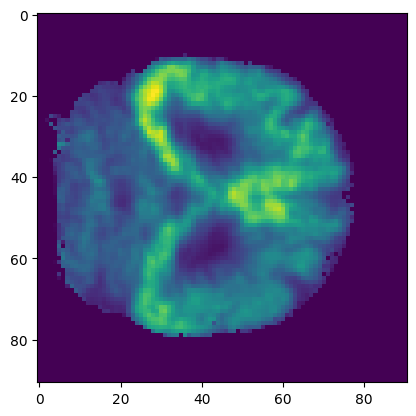

In [15]:

def show_sample(index, modality=0):
    sample = dm.ds[index]
    X = sample["X"]
    y = sample["y"]
    key = sample["key"]

    print(key)
    plt.imshow(X[modality,0,:,40,:])
    plt.show()

show_sample(80, modality=1)
